### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from PIL import Image
from collections import Counter

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


### 2. PARÁMETROS GLOBALES

In [2]:
IMG_SIZE      = 224
BATCH_SIZE    = 16                              # <-- Antes era 32
EPOCHS        = 75
PATIENCE_ES   = 10
PATIENCE_LR   = 5
NUM_CLASSES   = 10
NOMBRE_MODELO = 'resnet50_TL_optimizado'        # <-- cAntes era 'resnet50_TL'      

### 3. PREPROCESAMIENTO

In [3]:
# RUTAS DEL DATASET
base_dir  = '../../../Data/Cana_de_azucar'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

# Generador para entrenamiento con augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validación y test: SOLO normalización, sin augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Dataset de ENTRENAMIENTO
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

# Dataset de VALIDACIÓN
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset de TEST
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Imágenes de entrenamiento : {train_generator.samples}')
print(f'Imágenes de validación    : {val_generator.samples}')
print(f'Imágenes de test          : {test_generator.samples}')

Found 6112 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Imágenes de entrenamiento : 6112
Imágenes de validación    : 1309
Imágenes de test          : 1309


### 4. CONSTRUCCIÓN DEL MODELO RESNET50

In [4]:
# CARGAR RESNET50 CON PESOS DE IMAGENET
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

CAPAS_DESCONGELADAS = 50                                    # <-- Antes era 0

base_model.trainable = True
for layer in base_model.layers[:-CAPAS_DESCONGELADAS]:
    layer.trainable = False

# CREAR CAPA FINAL PERSONALIZADA
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),                                    # <-- Antes era 0.5
    layers.Dense(NUM_CLASSES, activation='softmax')
])

### 5. COMPILAR EL MODELO

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # <-- Antes era 'adam', que usa lr=0.001 por defecto
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 23,851,274
Trainable params: 17,214,090
Non-trainable params: 6,637,184
____________________________________

### 6. ENTRENAMIENTO

In [6]:
# 1. CALLBACKS 

# Callbacks para detener el entrenamiento si no mejora y guardar el mejor modelo
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES,
    restore_best_weights=True,
    verbose=1
)

# Guardar solo el mejor modelo basado en la pérdida de validación
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Reducir la tasa de aprendizaje si la pérdida de validación no mejora
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR,
    verbose=1
)

# 2. ENTRENAMIENTO
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/75
382/382 [==============================] - ETA: 0s - loss: 1.3491 - accuracy: 0.5697
Epoch 1: val_loss improved from inf to 0.31274, saving model to resnet50_TL_optimizado_weights.h5
382/382 [==============================] - 453s 1s/step - loss: 1.3491 - accuracy: 0.5697 - val_loss: 0.3127 - val_accuracy: 0.9198 - lr: 1.0000e-05
Epoch 2/75
382/382 [==============================] - ETA: 0s - loss: 0.3866 - accuracy: 0.9023
Epoch 2: val_loss improved from 0.31274 to 0.11132, saving model to resnet50_TL_optimizado_weights.h5
382/382 [==============================] - 464s 1s/step - loss: 0.3866 - accuracy: 0.9023 - val_loss: 0.1113 - val_accuracy: 0.9687 - lr: 1.0000e-05
Epoch 3/75
382/382 [==============================] - ETA: 0s - loss: 0.2130 - accuracy: 0.9396
Epoch 3: val_loss improved from 0.11132 to 0.06793, saving model to resnet50_TL_optimizado_weights.h5
382/382 [==============================] - 471s 1s/step - loss: 0.2130 - accuracy: 0.9396 - val_loss: 0.0679 - v

### 7. CURVAS DE ENTRENAMIENTO

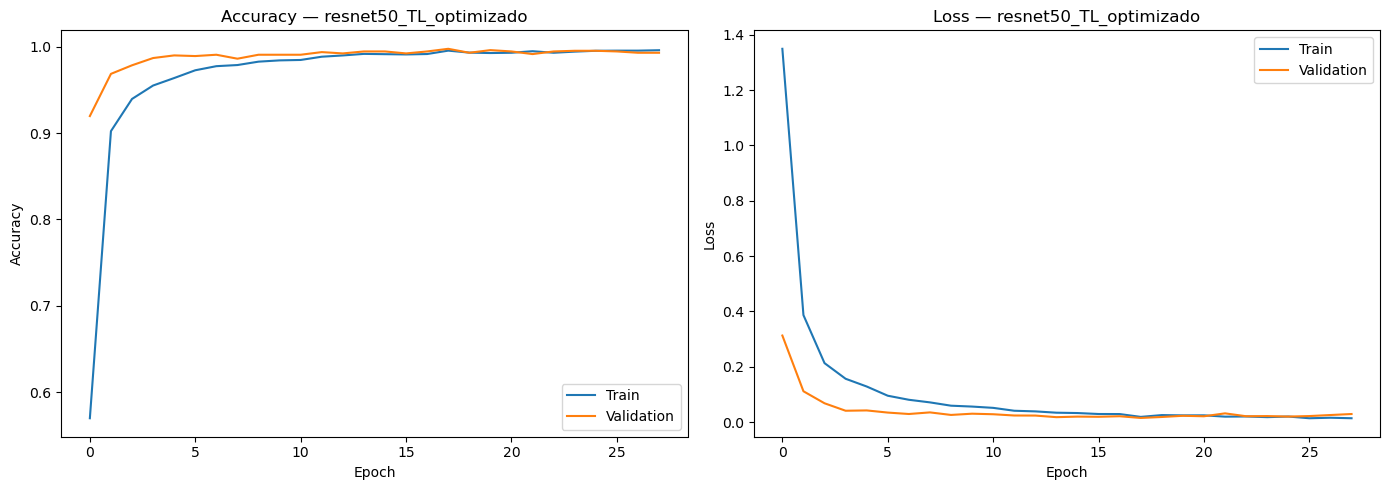

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title(f'Accuracy — {NOMBRE_MODELO}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(['Train', 'Validation'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title(f'Loss — {NOMBRE_MODELO}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

### 8. EVALUACIÓN FINAL EN TEST

In [8]:
# MÉTRICAS SOBRE EL CONJUNTO DE TEST (datos nunca vistos)
test_generator.reset()

# Accuracy y Loss en test
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTest Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

# Predicciones
predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

# F1 Score
f1 = f1_score(y_true, y_pred, average='weighted')
print(f'F1 Score      : {f1:.4f}')

# Reporte de clasificación (precision, recall, f1 por clase)
print('\n--- Reporte de clasificación ---')
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys(),
    digits=4
))

# Guardar resultados en .txt
with open(f'{NOMBRE_MODELO}_resultados.txt', 'w') as f:
    f.write(f'Modelo        : {NOMBRE_MODELO}\n')
    f.write(f'Test Accuracy : {test_accuracy:.4f}\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'F1 Score      : {f1:.4f}\n\n')
    f.write('--- Reporte de clasificación ---\n')
    f.write(classification_report(
        y_true,
        y_pred,
        target_names=test_generator.class_indices.keys(),
        digits=4        # ← 4 decimales
    ))

print(f'\nResultados guardados en {NOMBRE_MODELO}_resultados.txt')

82/82 [==============================] - 55s 661ms/step - loss: 0.0113 - accuracy: 0.9977

Test Accuracy : 0.9977
Test Loss     : 0.0113
82/82 [==============================] - 56s 656ms/step
F1 Score      : 0.9977

--- Reporte de clasificación ---
                  precision    recall  f1-score   support

          carbon     1.0000    1.0000    1.0000        75
   hoja_amarilla     1.0000    1.0000    1.0000       150
   mancha_anillo     1.0000    1.0000    1.0000       106
    mancha_parda     1.0000    1.0000    1.0000       150
         mosaico     1.0000    0.9933    0.9967       150
     muermo_rojo     1.0000    1.0000    1.0000       150
            roya     0.9933    0.9933    0.9933       150
           sanas     0.9868    1.0000    0.9934       150
           secas     1.0000    1.0000    1.0000        78
tizon_bacteriano     1.0000    0.9933    0.9967       150

        accuracy                         0.9977      1309
       macro avg     0.9980    0.9980    0.9980     

### 9. MATRIZ DE CONFUSIÓN

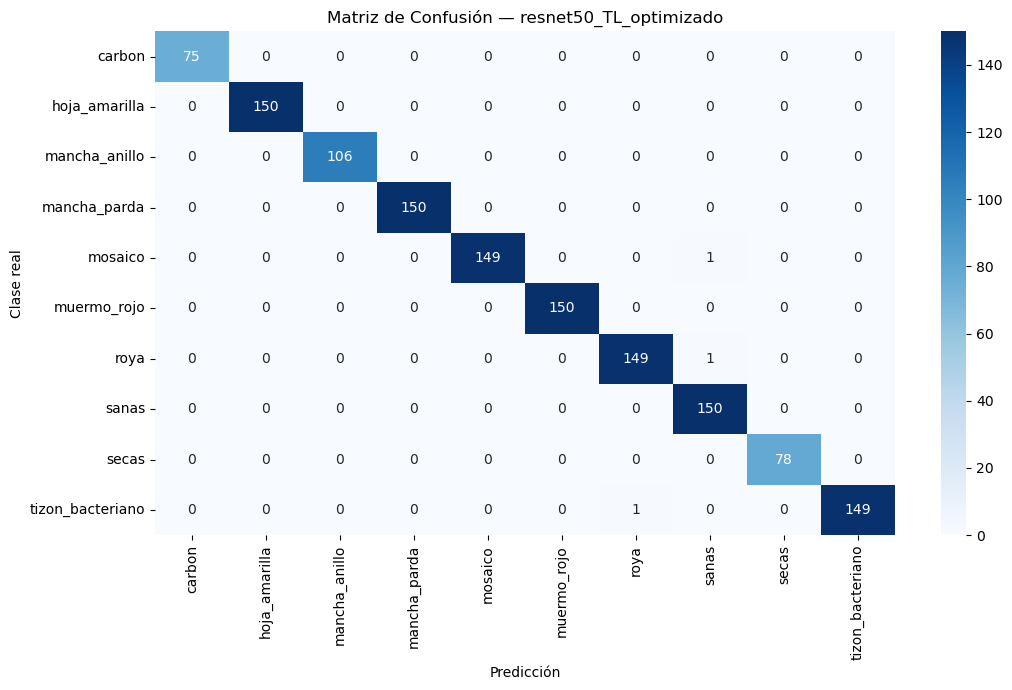

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title(f'Matriz de Confusión — {NOMBRE_MODELO}')
plt.tight_layout()
plt.show()

### 10. IMÁGENES CLASIFICADAS INCORRECTAMENTE

Pares con 5 o más confusiones:
  mosaico → sanas: 1 imágenes
  roya → sanas: 1 imágenes
  tizon_bacteriano → roya: 1 imágenes

Total de imágenes a mostrar: 3


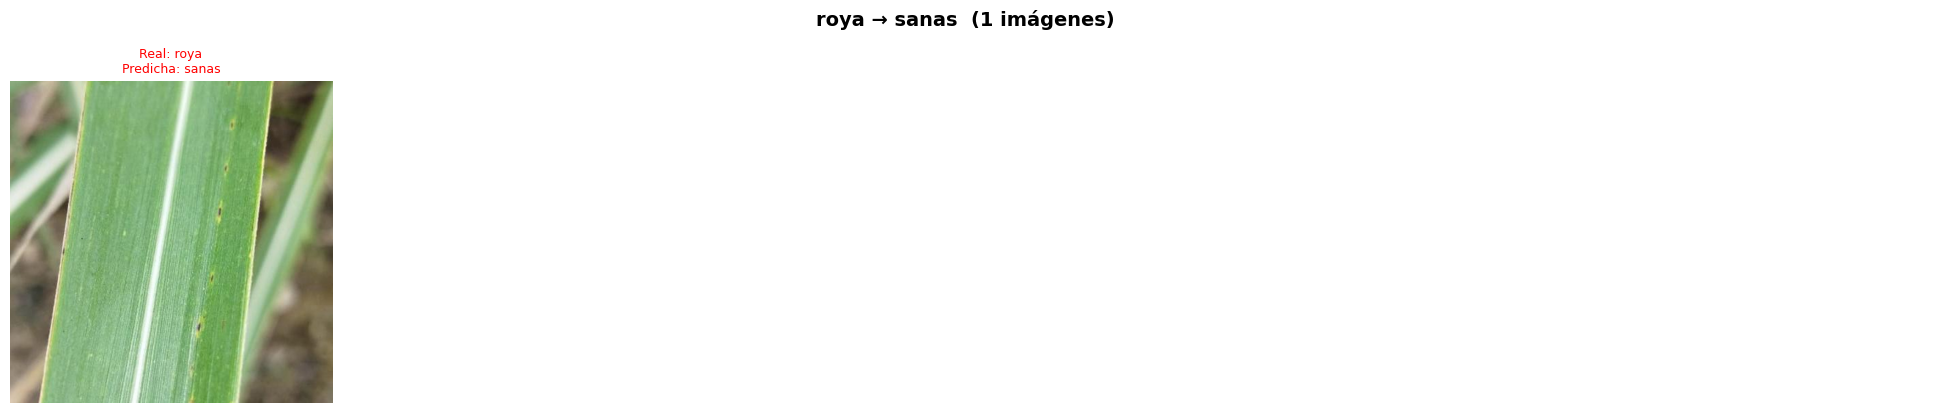

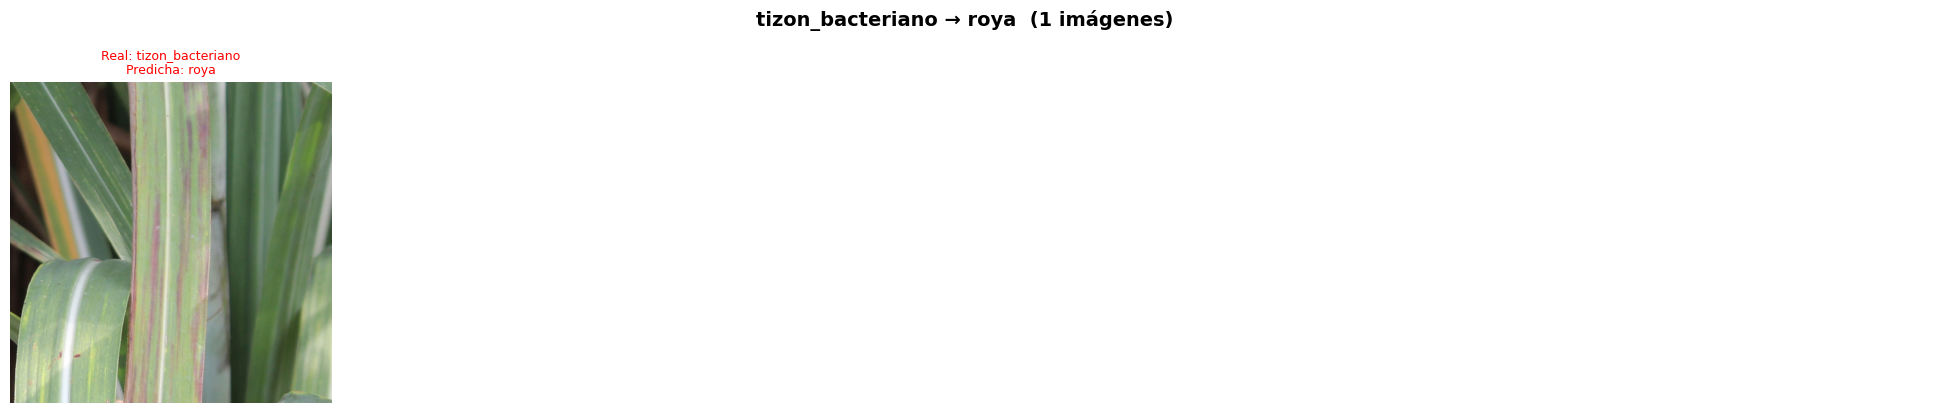

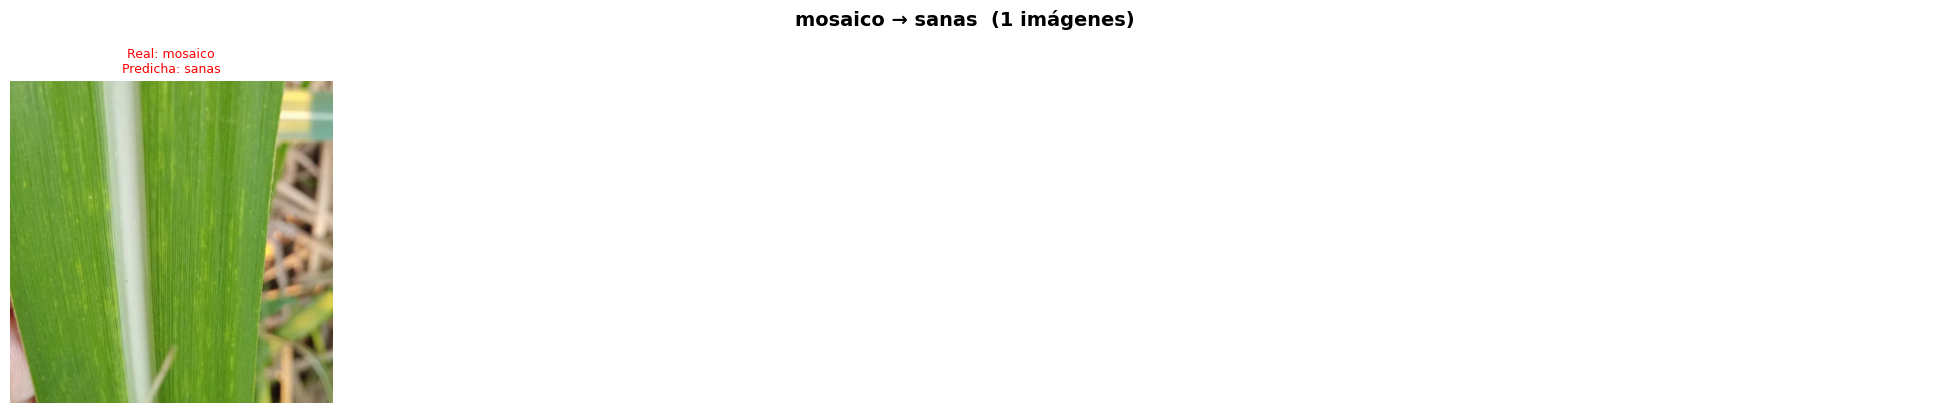

In [10]:
test_generator.reset()
filenames = test_generator.filenames

incorrectas = np.where(y_pred != y_true)[0]

class_indices  = test_generator.class_indices
indice_a_clase = {v: k for k, v in class_indices.items()}

pares        = [(indice_a_clase[y_true[i]], indice_a_clase[y_pred[i]]) for i in incorrectas]
conteo_pares = Counter(pares)

UMBRAL          = 1
pares_relevantes = {par for par, count in conteo_pares.items() if count >= UMBRAL}

print('Pares con 5 o más confusiones:')
for par, count in sorted(conteo_pares.items(), key=lambda x: -x[1]):
    if count >= UMBRAL:
        print(f'  {par[0]} → {par[1]}: {count} imágenes')

indices_filtrados = [
    i for i in incorrectas
    if (indice_a_clase[y_true[i]], indice_a_clase[y_pred[i]]) in pares_relevantes
]

print(f'\nTotal de imágenes a mostrar: {len(indices_filtrados)}')

base_dir = '../../../Data/Cana_de_azucar/test'

for par in sorted(pares_relevantes, key=lambda p: -conteo_pares[p]):
    clase_real, clase_predicha = par
    indices_par = [
        i for i in indices_filtrados
        if indice_a_clase[y_true[i]] == clase_real
        and indice_a_clase[y_pred[i]] == clase_predicha
    ]

    n_mostrar = len(indices_par)
    n_cols    = 5
    n_filas   = (n_mostrar + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, n_filas * 4))
    axes = axes.flatten()

    for j, idx in enumerate(indices_par):
        ruta_imagen = os.path.join(base_dir, filenames[idx])
        img = Image.open(ruta_imagen)
        axes[j].imshow(img)
        axes[j].set_title(
            f'Real: {clase_real}\nPredicha: {clase_predicha}',
            fontsize=9,
            color='red'
        )
        axes[j].axis('off')

    for j in range(n_mostrar, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        f'{clase_real} → {clase_predicha}  ({n_mostrar} imágenes)',
        fontsize=14,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

### 11. GUARDAR PESOS DEL MODELO

In [11]:
model.save_weights(f'{NOMBRE_MODELO}_weights.h5')
print(f'Pesos guardados como: {NOMBRE_MODELO}_weights.h5')

Pesos guardados como: resnet50_TL_optimizado_weights.h5
